# Notebook 03 — Modelo MVP


**Objetivo:** apoiar a elaboração do model card do modelo mvp descrito em `docs/model_card.md`.

## Imports e Setups

In [1]:
# Todo import de bibliotecas e configuração de ambiente para rodar o notebook deverão estar nesta célula.

import sys
import warnings
from pathlib import Path

import mlflow
import pandas as pd
from IPython.display import display
import yaml

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.exp import (
    build_artifact_name,
    build_cross_validate_comparison_table,
    build_default_cv,
    build_default_scoring,
    build_economic_comparison_table,
    build_notebook03_estimators,
    generate_oof_predictions_by_model,
    load_split_bundle_from_mlflow,
    resolve_notebook03_runs,
    save_figure_temp,
    set_mlflow_tracking,
    summarize_calibration_for_models,
)
from src.utils.mlflow_tracking import ensure_experiment, log_dataframe_artifact, log_metrics_safe, start_experiment_run
from src.utils.plots import (
    plot_calibration_curves_grid,
    plot_confusion_matrices_grid,
    plot_learning_curves_grid,
    plot_pr_curves_grid,
    plot_probability_histograms_grid,
    plot_roc_curves_grid,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

with open(PROJECT_ROOT / 'config' / 'config.yaml', encoding='utf-8') as f:
    config = yaml.safe_load(f)

TRACKING_URI = config['mlflow']['tracking_uri']
TARGET_COLUMN = config['data']['target']
INTERIM_DATA_PATH = PROJECT_ROOT / config['data']['interim_path']
MLFLOW_EXPERIMENT_NB03 = 'tc-f1-nb03-comparacao-modelos'
CAMPAIGN_COST = 100000.0
RETENTION_RATE = 0.10

client = set_mlflow_tracking(TRACKING_URI, workspace_root=PROJECT_ROOT)
cv = build_default_cv(
    n_splits=config['validation']['n_splits'],
    shuffle=config['validation']['shuffle'],
    random_state=config['experiment']['random_state'],
)
scoring = build_default_scoring()

print(f"Tracking URI: {TRACKING_URI}")
print(f"Target: {TARGET_COLUMN}")
print(f"Base intermediária: {INTERIM_DATA_PATH}")
print(f"Experimento NB03: {MLFLOW_EXPERIMENT_NB03}")
print(f"Campanha base: custo={CAMPAIGN_COST:.0f} | retenção={RETENTION_RATE:.2f}")


Tracking URI: sqlite:///mlflow.db
Target: Churn Value
Base intermediária: C:\Users\jooar\ds\portfolio\mle-f1-tech-challenge-fiap\data\interim\telecom_clean.csv
Experimento NB03: tc-f1-nb03-comparacao-modelos
Campanha base: custo=100000 | retenção=0.10


## Modelos em Comparação

- Regressão Logística (baseline inicial)
- MLP (baseline inicial)
- MLP Optuna
- XGBoost Optuna

## Recupera os Splits

In [2]:
split_bundle = load_split_bundle_from_mlflow(
    client=client,
    workspace_root=PROJECT_ROOT,
    data_path=INTERIM_DATA_PATH,
    target_column=TARGET_COLUMN,
)

X_train_val = split_bundle['X_train_val']
y_train_val = split_bundle['y_train_val']
X_test = split_bundle['X_test']
y_test = split_bundle['y_test']
metadata_train_val = split_bundle['metadata_train_val']
metadata_test = split_bundle['metadata_test']

print(f"X_train_val: {X_train_val.shape}")
print(f"y_train_val: {y_train_val.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")
display(metadata_train_val.head())


X_train_val: (4930, 21)
y_train_val: (4930,)
X_test: (2113, 21)
y_test: (2113,)


,CLTV,CustomerID
index,,
5963,3391,6918-UMQCG
596,3561,4140-MUHUG
1836,2270,5570-PTWEH
3535,4159,2054-PJOCK
228,5559,4315-MURBD


## Recuperando os Experimentos do MLFlow

In [3]:
run_registry = resolve_notebook03_runs(client)
upstream_runs_by_model = {
    'LogisticRegression': run_registry['logistic_baseline'],
    'MLP': run_registry['mlp_baseline'],
    'MLP Optuna': run_registry['mlp_optuna'],
    'XGBoost Optuna': run_registry['xgb_optuna'],
}

run_summary = pd.DataFrame(
    [
        {
            'modelo': model_name,
            'run_name': run.data.tags.get('mlflow.runName'),
            'run_id': run.info.run_id,
            'artifact_uri': run.info.artifact_uri,
        }
        for model_name, run in upstream_runs_by_model.items()
    ]
)

display(run_summary)


,modelo,run_name,run_id,artifact_uri
0,LogisticRegression,LogisticRegression,c78614b2fdef444c9ba9fc2077e3a2dc,mlflow-artifacts:/1/c78614b2fdef444c9ba9fc2077...
1,MLP,MLP,22319ddeae8e46ef894043613ab5a299,mlflow-artifacts:/1/22319ddeae8e46ef894043613a...
2,MLP Optuna,optuna_mlp,3132d9b960c947afa75163c1ca0679b8,mlflow-artifacts:/6/3132d9b960c947afa75163c1ca...
3,XGBoost Optuna,optuna_xgboost,fa0896c73c3542d087cf8a3fad49a477,mlflow-artifacts:/6/fa0896c73c3542d087cf8a3fad...


## Refit e Geração de Probabilidades

In [4]:
comparison_models = build_notebook03_estimators(
    run_registry,
    workspace_root=PROJECT_ROOT,
    y_reference=y_train_val,
)

pd.DataFrame(
    {
        'modelo': list(comparison_models.keys()),
        'estimador': [type(model).__name__ for model in comparison_models.values()],
    }
)


,modelo,estimador
0,LogisticRegression,Pipeline
1,MLP,Pipeline
2,MLP Optuna,Pipeline
3,XGBoost Optuna,Pipeline


In [5]:
oof_predictions = generate_oof_predictions_by_model(
    comparison_models,
    X=X_train_val,
    y=y_train_val,
    cv=cv,
)

{
    model_name: oof_df.head()
    for model_name, oof_df in oof_predictions.items()
}


{'LogisticRegression':    row_index  fold  y_true     proba  pred_0_5               model
 0          0     6       1  0.583940         1  LogisticRegression
 1          1    10       1  0.545224         1  LogisticRegression
 2          2     8       1  0.668589         1  LogisticRegression
 3          4     2       1  0.305508         0  LogisticRegression
 4          6     1       1  0.874282         1  LogisticRegression,
 'MLP':    row_index  fold  y_true     proba  pred_0_5 model
 0          0     6       1  0.617746         1   MLP
 1          1    10       1  0.708473         1   MLP
 2          2     8       1  0.632227         1   MLP
 3          4     2       1  0.285105         0   MLP
 4          6     1       1  0.916561         1   MLP,
 'MLP Optuna':    row_index  fold  y_true     proba  pred_0_5       model
 0          0     6       1  0.978732         1  MLP Optuna
 1          1    10       1  0.646669         1  MLP Optuna
 2          2     8       1  0.982031      

## Comparação Técnica

In [6]:
ensure_experiment(MLFLOW_EXPERIMENT_NB03)

NB03_BASE_TAGS = {
    'source_notebook': '03_modelo_mvp',
    'phase': 'pre_mlp_production',
    'comparison_scope': 'train_val_oof',
}

NB03_RUN_NAMES = {
    'table': 'nb03_tabela_comparacao_modelos',
    'roc_pr': 'nb03_curvas_discriminacao',
    'learning': 'nb03_curvas_aprendizado',
    'confusion': 'nb03_matrizes_confusao',
    'calibration_metrics': 'nb03_calibracao_metricas',
    'calibration_curve': 'nb03_calibracao_curva',
    'prob_hist': 'nb03_histograma_probabilidades',
    'economics_pure': 'nb03_analise_economica_puro',
    'economics_cltv': 'nb03_analise_economica_cltv',
}

run_blueprint = pd.DataFrame(
    [
        {'bloco': key, 'run_name': value}
        for key, value in NB03_RUN_NAMES.items()
    ]
)

display(run_blueprint)


2026/05/01 22:28:59 INFO mlflow.tracking.fluent: Experiment with name 'tc-f1-nb03-comparacao-modelos' does not exist. Creating a new experiment.


,bloco,run_name
0,table,nb03_tabela_comparacao_modelos
1,roc_pr,nb03_curvas_discriminacao
2,learning,nb03_curvas_aprendizado
3,confusion,nb03_matrizes_confusao
4,calibration_metrics,nb03_calibracao_metricas
5,calibration_curve,nb03_calibracao_curva
6,prob_hist,nb03_histograma_probabilidades
7,economics_pure,nb03_analise_economica_puro
8,economics_cltv,nb03_analise_economica_cltv


### Tabela Comparativa de Métrica

In [7]:
comparison_table = build_cross_validate_comparison_table(
    comparison_models,
    X=X_train_val,
    y=y_train_val,
    cv=cv,
    scoring=scoring,
)


In [8]:
display(comparison_table.round(4))


,modelo,PR-AUC,PR-AUC gap (%),ROC-AUC,ROC-AUC gap (%),Recall,Recall gap (%),Precision,Precision gap (%),F1-Score,F1-Score gap (%),fit_time(mean),score_time(mean)
0,XGBoost Optuna,0.9601,-1.2340,0.9843,-0.5110,0.9457,-2.3686,0.8083,-2.1990,0.8714,-2.2997,0.1031,0.0235
1,MLP Optuna,0.9389,-0.5073,0.9759,-0.2208,0.9388,-0.6178,0.7690,-0.5750,0.8453,-0.6015,1.8872,0.0197
2,LogisticRegression,0.6798,-0.7764,0.8573,-0.5927,0.8142,-0.5189,0.5310,-0.3409,0.6426,-0.4401,0.0273,0.0104
3,MLP,0.6721,-3.7437,0.8554,-1.8367,0.8020,-3.2978,0.5253,-2.8628,0.6340,-3.0971,0.7688,0.0114


In [9]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['table'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Tabela comparativa treino vs validação para os modelos benchmark e modelo candidato do notebook 03.',
    },
):
    mlflow.set_tag('models_compared', ', '.join(comparison_models.keys()))
    log_dataframe_artifact(comparison_table.round(6), 'comparison_table_metrics.csv')


### Curvas e Matriz de Confusão

#### PR-AUC e ROC-AUC

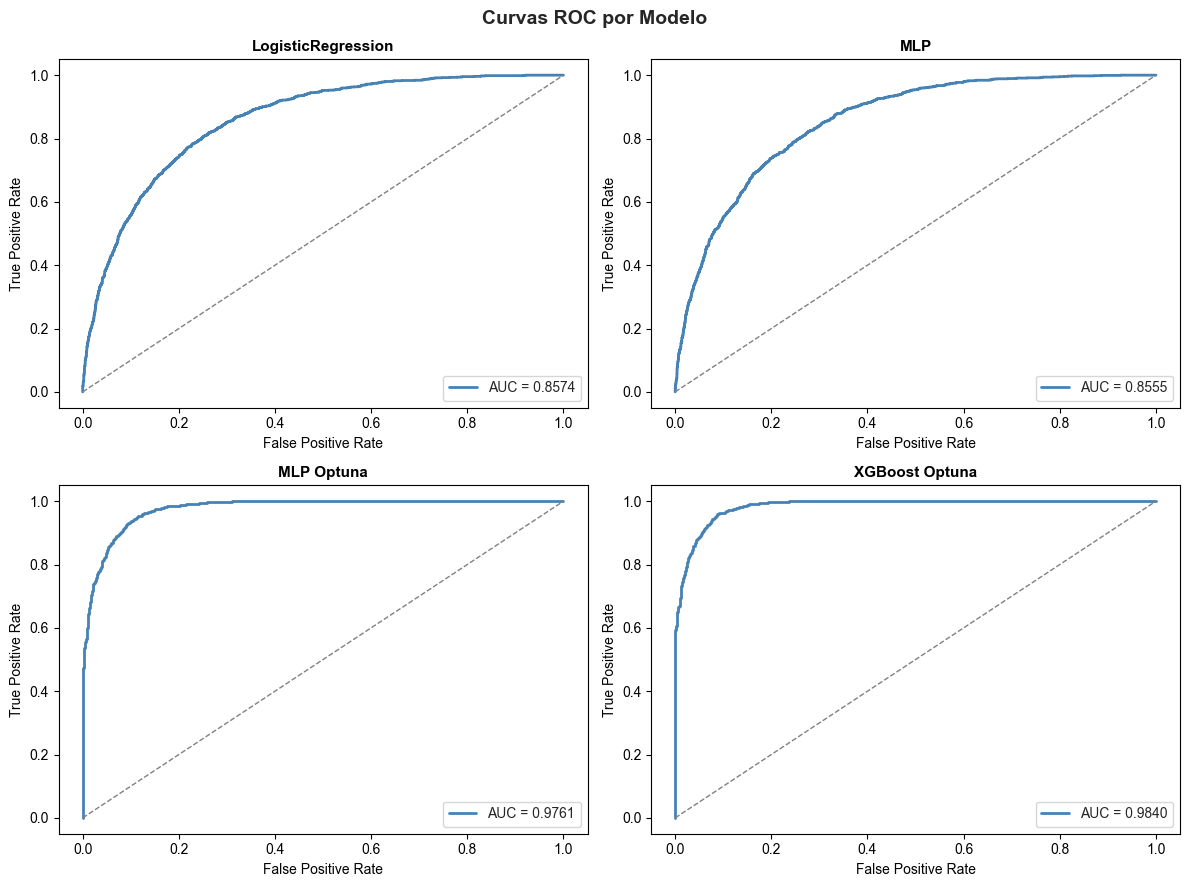

In [11]:
roc_fig = plot_roc_curves_grid(oof_predictions, show=True)


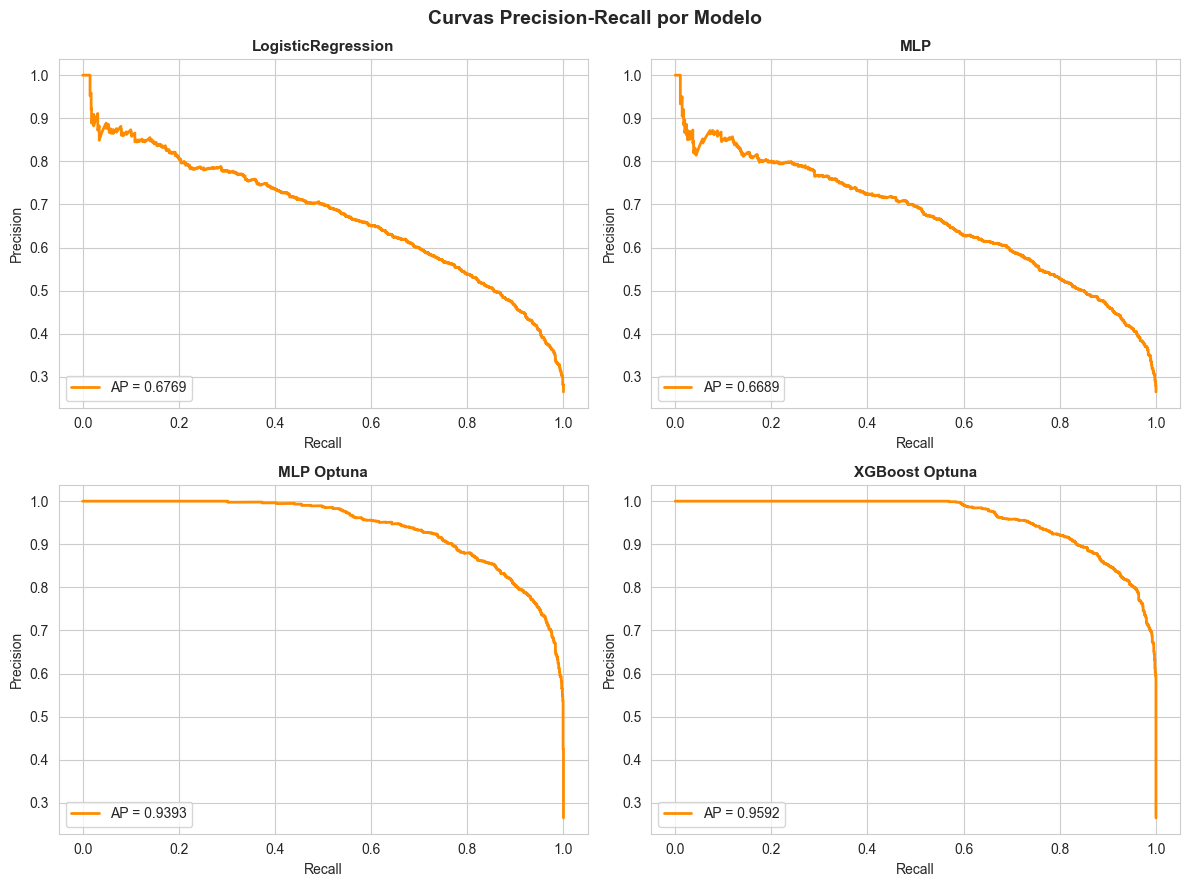

In [12]:
pr_fig = plot_pr_curves_grid(oof_predictions, show=True)


In [13]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['roc_pr'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Curvas ROC e Precision-Recall geradas a partir de probabilidades OOF no conjunto de desenvolvimento.',
    },
):
    with start_experiment_run(
        MLFLOW_EXPERIMENT_NB03,
        'nb03_curva_roc',
        nested=True,
        tags={**NB03_BASE_TAGS},
    ):
        mlflow.log_artifact(str(save_figure_temp(roc_fig, 'roc_curves_grid.png')))
    with start_experiment_run(
        MLFLOW_EXPERIMENT_NB03,
        'nb03_curva_pr',
        nested=True,
        tags={**NB03_BASE_TAGS},
    ):
        mlflow.log_artifact(str(save_figure_temp(pr_fig, 'pr_curves_grid.png')))


#### Learning Curves

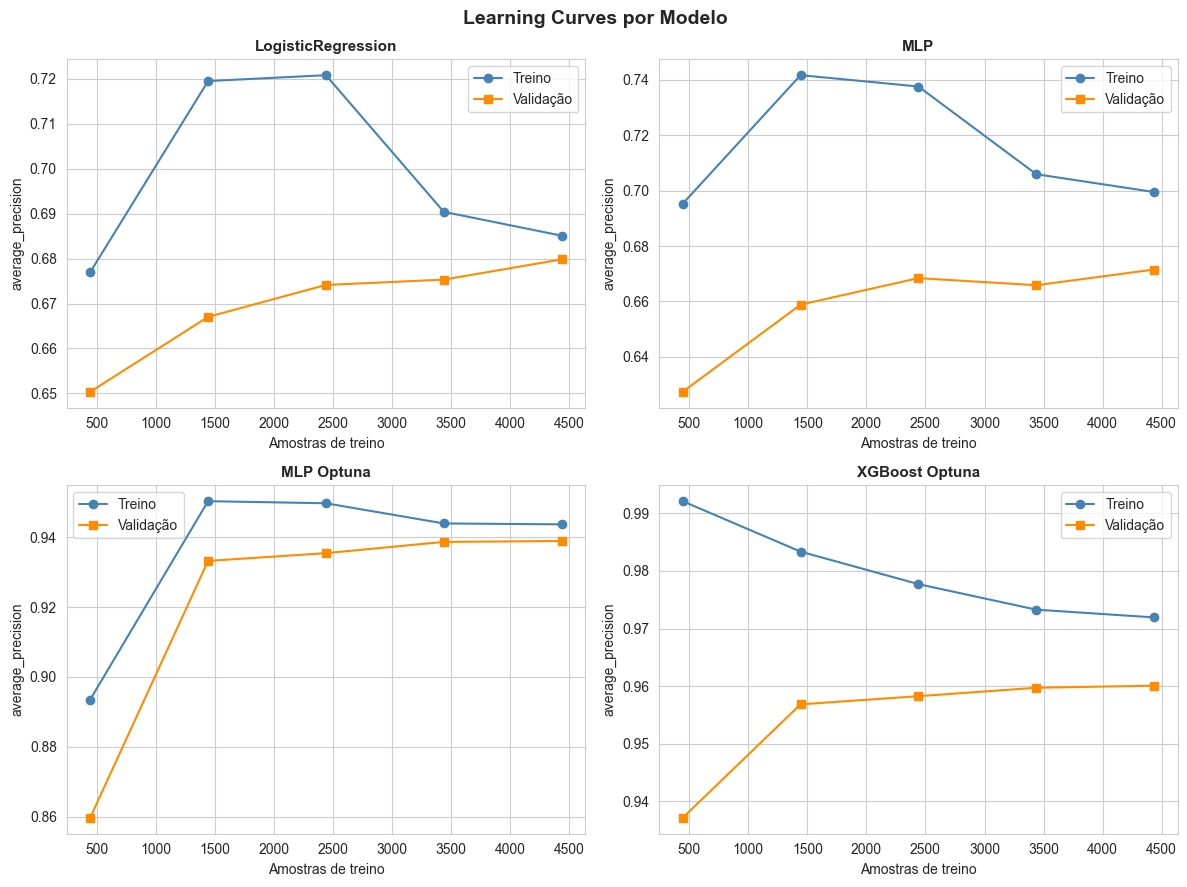

In [14]:
learning_curve_fig = plot_learning_curves_grid(
    comparison_models,
    X=X_train_val,
    y=y_train_val,
    cv=cv,
    show=True,
)


In [15]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['learning'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Learning curves para diagnóstico de comportamento treino vs validação dos modelos comparados.',
    },
):
    mlflow.log_artifact(str(save_figure_temp(learning_curve_fig, 'learning_curves_grid.png')))


### Matriz de Confusão

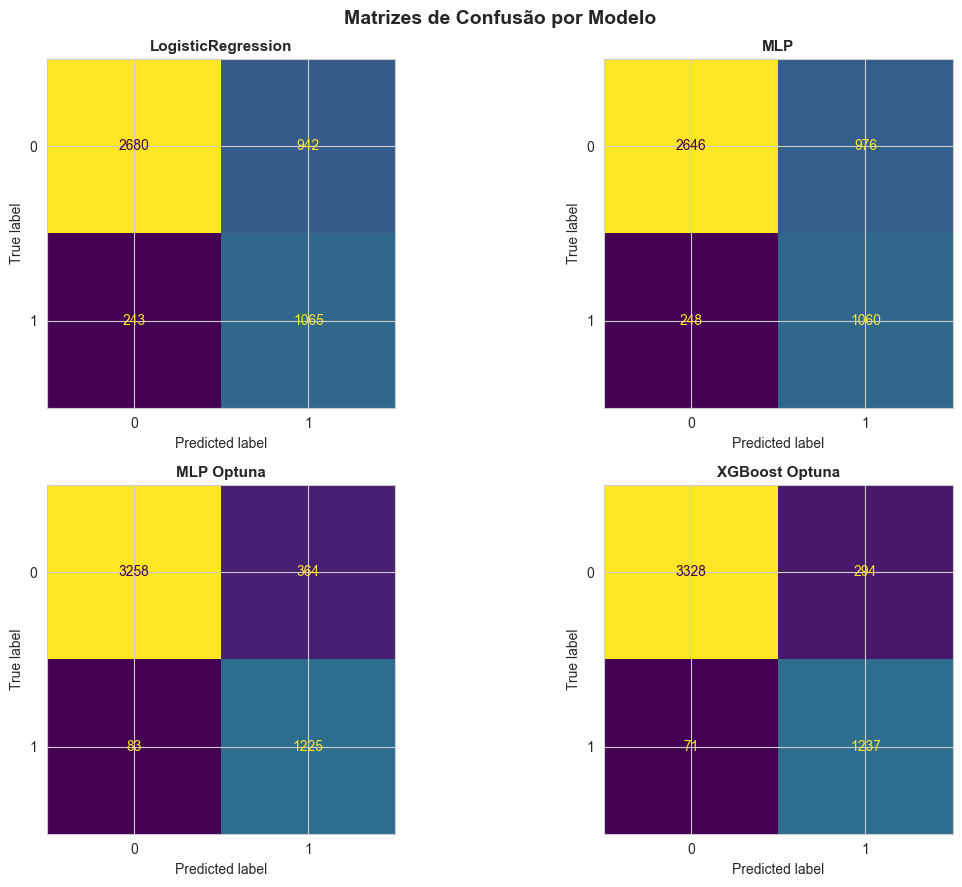

In [16]:
confusion_matrix_fig = plot_confusion_matrices_grid(
    oof_predictions,
    threshold=0.5,
    show=True,
)


In [17]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['confusion'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Matrizes de confusão OOF com threshold padrão de 0.5 para os modelos comparados.',
    },
):
    mlflow.log_artifact(str(save_figure_temp(confusion_matrix_fig, 'confusion_matrices_grid.png')))


### Checagem de Calibração

#### Reliability Curve

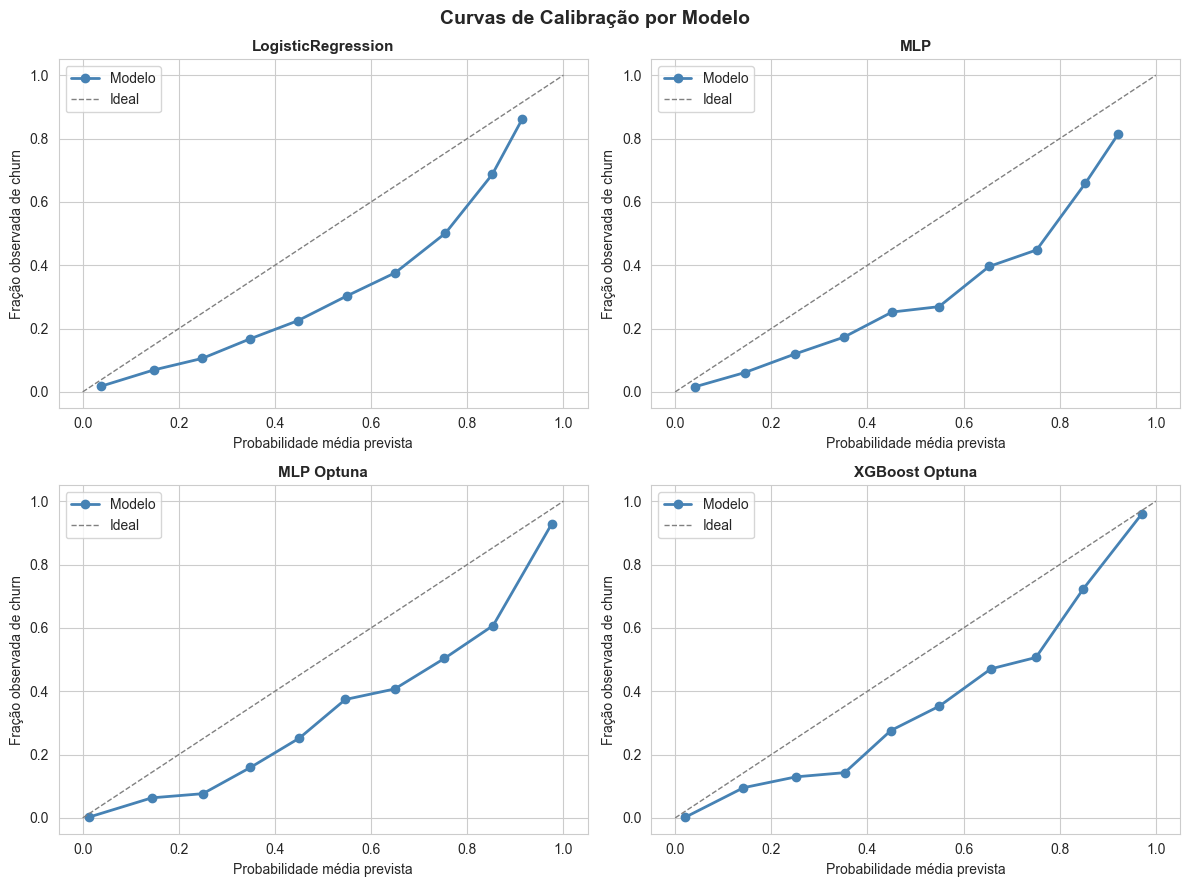

In [18]:
calibration_curve_fig = plot_calibration_curves_grid(
    oof_predictions,
    n_bins=10,
    show=True,
)


In [19]:
calibration_summary = summarize_calibration_for_models(
    oof_predictions,
    n_bins=10,
)

display(calibration_summary.round(6))


,modelo,brier_score,ece
0,LogisticRegression,0.159229,0.141339
1,MLP,0.163116,0.148366
2,MLP Optuna,0.065724,0.062142
3,XGBoost Optuna,0.051794,0.045806


In [20]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['calibration_metrics'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Métricas diagnósticas de calibração (Brier Score e ECE) para os modelos comparados.',
    },
):
    for row in calibration_summary.to_dict(orient='records'):
        model_name = row['modelo']
        upstream_run = upstream_runs_by_model[model_name]
        with start_experiment_run(
            MLFLOW_EXPERIMENT_NB03,
            f"nb03_calibration_{model_name.lower().replace(' ', '_')}",
            nested=True,
            tags={
                **NB03_BASE_TAGS,
                'upstream_run_id': upstream_run.info.run_id,
            },
        ):
            log_metrics_safe(
                {
                    'brier_score': row['brier_score'],
                    'ece': row['ece'],
                }
            )


In [21]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['calibration_curve'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Reliability curves geradas a partir das probabilidades OOF dos modelos em comparação.',
    },
):
    mlflow.log_artifact(str(save_figure_temp(calibration_curve_fig, 'calibration_curves_grid.png')))


#### Histograma de probabilidades

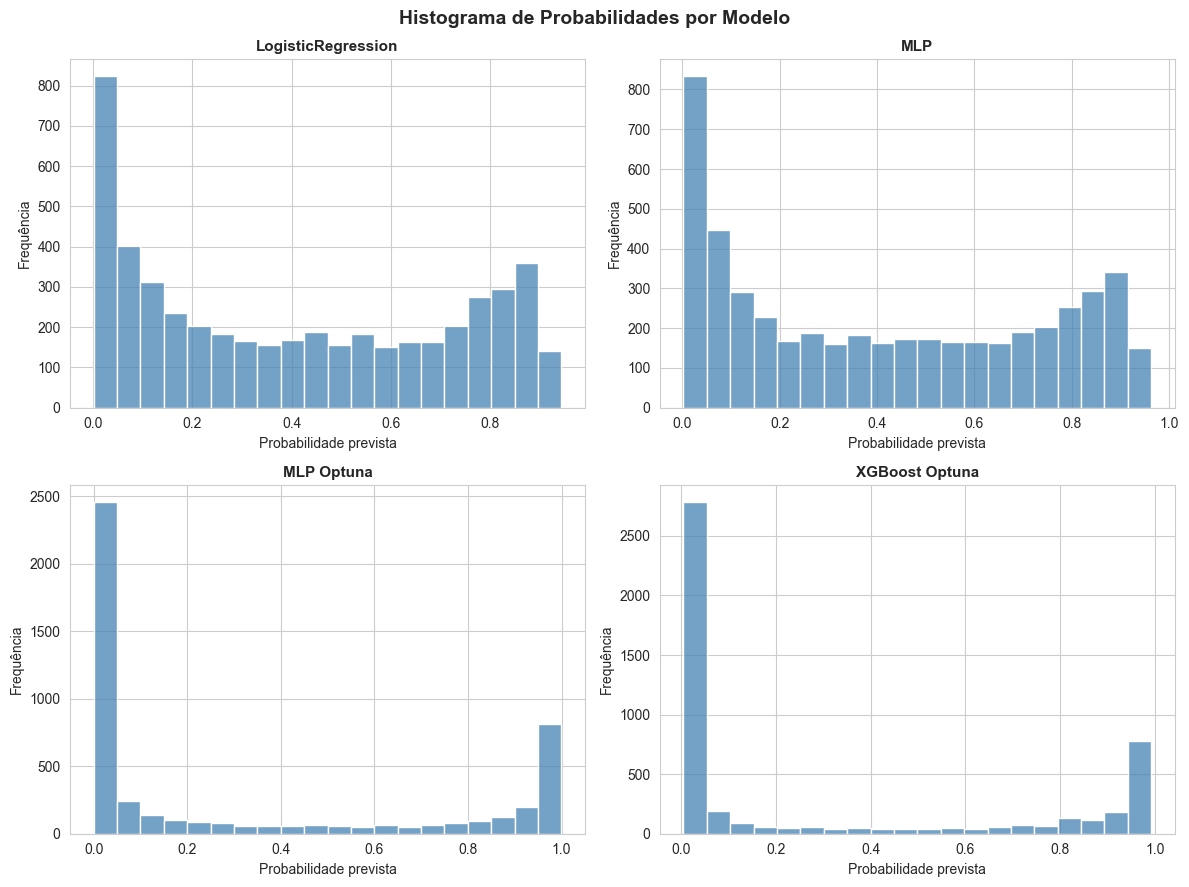

In [22]:
probability_hist_fig = plot_probability_histograms_grid(
    oof_predictions,
    show=True,
)


In [23]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['prob_hist'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Histogramas de probabilidade para inspeção da distribuição dos scores OOF por modelo.',
    },
):
    mlflow.log_artifact(str(save_figure_temp(probability_hist_fig, 'probability_histograms_grid.png')))


### Análise Econômica

#### Cenários a serem explorados

- p puro
- p ajustado por peso/beneficio baseado em `CLTV`

#### Métricas Utilizadas

- IEL
- ROI

As descrição das métricas podem ser encontradas em `docs/KPI.md`

#### Premissas
- custo_campanha = 100000
- taxa de retençao = 0.1

#### Cenários a serem explorados

- p puro
- p ajustado por peso/beneficio baseado em `CLTV`

#### Cenário 1 - probabilidades puro

In [36]:
economic_analysis_pure = build_economic_comparison_table(
    oof_predictions,
    metadata=metadata_train_val,
    campaign_cost=CAMPAIGN_COST,
    retention_rate=RETENTION_RATE,
    threshold=0.5,
)

display(economic_analysis_pure.round(2))


,modelo,tp,fp,fn,tn,vr,vrec,vp,cmca,vd,iel,roi,threshold,campaign_cost,retention_rate
0,XGBoost Optuna,1237,294,71,3328,4710069.07,471006.91,98257.74,65.32,19203.14,353546.03,2.73,0.5,100000.0,0.1
1,MLP Optuna,1225,364,83,3258,4701641.43,470164.14,117913.13,62.93,22907.49,329343.52,2.52,0.5,100000.0,0.1
2,LogisticRegression,1065,942,243,2680,3429784.50,342978.45,325701.04,49.83,46935.72,-29658.31,-0.83,0.5,100000.0,0.1
3,MLP,1060,976,248,2646,3462804.04,346280.40,346465.81,49.12,47937.13,-48122.53,-1.00,0.5,100000.0,0.1


In [25]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['economics_pure'],
    tags={
        **NB03_BASE_TAGS,
        'scenario': 'p_puro',
        'mlflow.note.content': 'Análise econômica com probabilidades OOF puras, custo total de campanha fixado em 100000 e taxa de retenção de 10%.',
    },
):
    log_dataframe_artifact(economic_analysis_pure.round(6), 'economic_analysis_puro.csv')
    for row in economic_analysis_pure.to_dict(orient='records'):
        model_name = row['modelo']
        upstream_run = upstream_runs_by_model[model_name]
        with start_experiment_run(
            MLFLOW_EXPERIMENT_NB03,
            f"nb03_economics_pure_{model_name.lower().replace(' ', '_')}",
            nested=True,
            tags={
                **NB03_BASE_TAGS,
                'scenario': 'p_puro',
                'upstream_run_id': upstream_run.info.run_id,
            },
        ):
            log_metrics_safe(
                {
                    'iel': row['iel'],
                    'roi': row['roi'],
                    'vr': row['vr'],
                    'vrec': row['vrec'],
                    'vp': row['vp'],
                    'vd': row['vd'],
                }
            )
            log_dataframe_artifact(
                oof_predictions[model_name].copy(),
                build_artifact_name('oof_prob', model_name, 'csv'),
            )


#### Cenário 2 - probabilidades ponderadas por CLTV

In [26]:
cltv_sample_weight = metadata_train_val.loc[X_train_val.index, 'CLTV']

oof_predictions_cltv = generate_oof_predictions_by_model(
    comparison_models,
    X=X_train_val,
    y=y_train_val,
    cv=cv,
    sample_weight=cltv_sample_weight,
)

{
    model_name: oof_df.head()
    for model_name, oof_df in oof_predictions_cltv.items()
}


{'LogisticRegression':    row_index  fold  y_true     proba  pred_0_5               model
 0          0     6       1  0.621886         1  LogisticRegression
 1          1    10       1  0.551513         1  LogisticRegression
 2          2     8       1  0.678326         1  LogisticRegression
 3          4     2       1  0.325361         0  LogisticRegression
 4          6     1       1  0.890667         1  LogisticRegression,
 'MLP':    row_index  fold  y_true     proba  pred_0_5 model
 0          0     6       1  0.566191         1   MLP
 1          1    10       1  0.718788         1   MLP
 2          2     8       1  0.719959         1   MLP
 3          4     2       1  0.118821         0   MLP
 4          6     1       1  0.870957         1   MLP,
 'MLP Optuna':    row_index  fold  y_true     proba  pred_0_5       model
 0          0     6       1  0.977737         1  MLP Optuna
 1          1    10       1  0.705130         1  MLP Optuna
 2          2     8       1  0.982854      

In [37]:
economic_analysis_cltv = build_economic_comparison_table(
    oof_predictions_cltv,
    metadata=metadata_train_val,
    campaign_cost=CAMPAIGN_COST,
    retention_rate=RETENTION_RATE,
    threshold=0.5,
)

display(economic_analysis_cltv.round(2))


,modelo,tp,fp,fn,tn,vr,vrec,vp,cmca,vd,iel,roi,threshold,campaign_cost,retention_rate
0,XGBoost Optuna,1235,293,73,3329,4717900.08,471790.01,96769.84,65.45,19175.39,355844.78,2.75,0.5,100000.0,0.1
1,MLP Optuna,1219,358,89,3264,4696533.35,469653.34,130657.39,63.41,22701.33,316294.62,2.39,0.5,100000.0,0.1
2,LogisticRegression,1079,990,229,2632,3517173.56,351717.36,306837.69,48.33,47849.20,-2969.54,-0.55,0.5,100000.0,0.1
3,MLP,1048,935,260,2687,3421459.21,342145.92,357413.46,50.43,47150.78,-62418.32,-1.15,0.5,100000.0,0.1


In [28]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['economics_cltv'],
    tags={
        **NB03_BASE_TAGS,
        'scenario': 'p_ponderado_cltv',
        'mlflow.note.content': 'Análise econômica com probabilidades OOF geradas a partir de treino ponderado por CLTV via sample_weight.',
    },
):
    log_dataframe_artifact(economic_analysis_cltv.round(6), 'economic_analysis_cltv_weighted.csv')
    for row in economic_analysis_cltv.to_dict(orient='records'):
        model_name = row['modelo']
        upstream_run = upstream_runs_by_model[model_name]
        with start_experiment_run(
            MLFLOW_EXPERIMENT_NB03,
            f"nb03_economics_cltv_{model_name.lower().replace(' ', '_')}",
            nested=True,
            tags={
                **NB03_BASE_TAGS,
                'scenario': 'p_ponderado_cltv',
                'upstream_run_id': upstream_run.info.run_id,
            },
        ):
            log_metrics_safe(
                {
                    'iel': row['iel'],
                    'roi': row['roi'],
                    'vr': row['vr'],
                    'vrec': row['vrec'],
                    'vp': row['vp'],
                    'vd': row['vd'],
                }
            )
            log_dataframe_artifact(
                oof_predictions_cltv[model_name].copy(),
                build_artifact_name('oof_prob_cltv', model_name, 'csv'),
            )


#### Conclusão

- Nota-se uma pequena melhora operacional em FP e VD, porém não foi suficiente;
- O modelo deixa passar mais churns valiosos (FN subiu e VP subiu bastante);
- a ponderação por sample_weight não ajudou de forma consistente, o cenário p puro é melhor;
- a ponderação trouxe resultados positivos em outros modelos como a regressão logística, o que sugere que o efeito depende muito da arquitetura.
- a recomendação final é manter a abordagem p puro e utilizar CLTV na priorização da campanha por rankeamento de score;

## Performance do Modelo MLP (produção)

In [ ]:
#TODO: Setar um Experiment no MLFlow tc-f1-nb03-MLP-production-performance
    # Run Pai 1 > Otimização do Threshold
        # Otimizar o Threshold e logar o best threshold encontrado para o MLP Optuna
        # logar as métricas econômicas (IEL, ROI, VR, VRec, VP, VD) para o threshold ótimo encontrado
        # logar as métricas ténicas (PR-AUC, ROC-AUC, Recall, Precision, F1-Score) para o threshold ótimo encontrado
        # subir o artefato gráfico gerado ROI x Threshold
        # subir o artefato gráfico gerado comparando a matriz de confusão com threshold 0.5 e a matriz de confusão com o best_threshold encontrado
    # Run Pai 2 > Stress Test
        # Nested Run 1 > Análise de sensibilidade do ROI
            # Realiza uma análise de sensibilidade do ROI variando Taxa de retenção e Custo de Campanha para o MLP Optuna com o threshold ótimo
            # Sobe o Gráfico gerado de sensibilidade do ROI como artefato no MLFlow
        # Nested Run 2 > Análise de Custo de Cammpanha x Retenção x ROI (Heatmap)
            # cria um grid utilizando os valores de custo_campanha e retencao para calcular o ROI com o threshold ótimo e gerar um gráfico de calor (heatmap) de Retenção x Custo de Campanha com o ROI como valor representado no heatmap
            # sobe o gráfico de calor gerado como artefato no MLFlow
    # Run Pai 3 > Avaliação no Holdout
        # Refit no conjunto de dados completo e avaliação no conjunto de holdout com o best_threshold encontrado para o MLP Optuna
        # Nested Run 1 > MLP Optuna Holdout Performance
            # reportar as métricas técnicas e econômicas no holdout para o modelo final com o best_threshold encontrado
            # criar uma lista com o nome das features do modelo e logar como artefato no MLFlow
            # subir uma matriz de confusão no holdout como artefato no mflow 
            # subir um subplot PR-AUC e ROC-AUC no holdout como artefato no mlflow
            # subir um histograma de probabilidades no holdout como artefato no mlflow
            # subir o subplot dos gráficos SHAP de explicabilidade do modelo no mlflow
            # subir artefatos gerados na análise de fairness como artefato no mlflow

### Otimização do Threshold

In [ ]:
# TODO: Otimiza Treshold para maior ROI apenas para o MLP Optuna
    # Variar o threshold de 0 a 1 com passo 0.1

In [ ]:
# TODO: Retorna um Gráfico ROI x Threshold para o MLP Optuna

In [ ]:
# TODO: plota um subplot comparativo entre a matriz de confusao com MLP Optuna thr=0.5 e a matriz de confusao com MLP Optuna com o best_threshold encontrado

In [ ]:
# TODO: Retorna um Output com Logging Estruturado
    # Trazer no Logging o Melhor Threshold
    # Trazer no Logging as métricas econômicas (IEL, ROI, VR, VRec, VP, VD) para o threshold ótimo encontrado apenas para o MLP Optuna
    # Trazer no Logging as métricas ténicas (PR-AUC, ROC-AUC, Recall, Precision, F1-Score) para o threshold ótimo encontrado apenas para o MLP Optuna
    # Comparar Ganho Econômico Percentual em relação ao ROI do Baseline de Regressão Logística, MLP inicial e MLP Optuna thr=0.5

In [ ]:
# TODO: Transforma o Gráfico ROI x Threshold para o MLP Optuna em um artefato e loga no MLFlow
# TODO: Logar as Métricas técinas e econômicas para o threshold ótimo encontrado para o MLP Optuna no MLFlow
# TODO: Transforma o subplot comparativo entre a matriz de confusao com MLP Optuna thr=0.5 e a matriz de confusao com MLP Optuna com o best_threshold encontrado em um artefato e loga no MLFlow

### Stress-Test: Retenção x ROI

In [ ]:
# TODO: Retorna uma Tabela Retençao x ROI com um valor de campanha fixo em 100k
    # variar Retencao de 0 a 1 variando 0.1
    # utilizar best_threshold

In [ ]:
# TODO: Retorna um gráfico de Retençao x ROI

In [ ]:
# TODO: Transformar a Tabela de retenção e o gráfico em artefatos e logar no MLFlow

### Campanha x Retenção x ROI (heatmap)

In [ ]:
custo_campanha = [25000, 50000, 100000, 200000, 400000, 800000, 1000000]
retencao = [0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]

In [ ]:
# TODO: cria um grid utilizando os valores de custo_campanha e retencao para calcular o ROI e gerar um gráfico de calor (heatmap) de Retenção x Custo de Campanha com o ROI como valor representado no heatmap
    # coloração azul para ROI positivo e vermelha para ROI negativo, variando a intensidade da cor de acordo com o valor do ROI
    # utilizar o best_threshold encontrado para o MLP Optuna

In [ ]:
# TODO: transforma o gráfico em artefato e loga no mlflow

### Análise no Holdout

In [ ]:
# TODO: Refit na Base inteira e Avaliação no Holdout
    # faz o refit do modelo MLP Optuna com o best_threshold encontrado utilizando a base de dados completa (treino + validação) e avalia no holdout
    # mostrar as métricas técnicas e econômicas no holdout para o modelo final com o best_threshold encontrado em um loggin estruturado no output da célula  

In [ ]:
# TODO: Cria uma matriz de confusão no holdout para o modelo final 

In [ ]:
# TODO: Cria um subplot PR-AUC e ROC-AUC no holdout para o modelo final

In [ ]:
# TODO: Cria um histograma de probabilidades no holdout para o modelo final

In [ ]:
# TODO: Transforma a matriz de confusão em um artefato e loga no MLFlow
# TODO: Transforma o subplot PR-AUC e ROC-AUC no holdout para o modelo final em um artefato e loga no MLFlow
# TODO: Transforma o histograma de probabilidades no holdout para o modelo final em um artefato e loga no MLFlow
# TODO: Logar as métricas técnicas e econômicas no holdout para o modelo final com o best_threshold encontrado

### Interpretabilidade da Rede Neural (SHAP)

In [ ]:
#TODO> plota um subplot 1 linha e 2 colunas com SHAP summary plot dot e bar

In [ ]:
#TODO: transforma o gráfico em artefato e loga no mlflow

### Análise de Fairness

In [ ]:
# TODO: Elaborar uma Análise de Fairness utilizando o Fairlearn.
    # Vamos Avaliar as features: Senior Citizen, Partner, Dependents e Contract
    # Métrica selection rate, Recall, precision, f1-score, fpr, fnr
    # usar by_group, difference(), ratio()
    # calcular as métrica classicas demographic parity, equalized odds difference e equalized odds ratio
    # um relatório completo para cada feature analisada com as métricas calculadas e os gráficos gerados (ex: bar plot de selection rate por grupo, gráfico de barras comparando recall, precision e f1-score por grupo, gráfico de barras comparando fpr e fnr por grupo) e logar cada relatório como artefato no MLFlow

In [ ]:
# TODO: exibir relatório de fairness no notebook por métrica

In [ ]:
# TODO: exibir o subplot dos gráficos de fairness no notebook
    # um subplot por feature analisada

In [ ]:
# TODO: consolidar relatórios gerados por features e logar como um artefato no mflow

In [ ]:
# TODO: consolidar os subplots gerados e logar como artefatos no mlflow